In [7]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [ ]:
df = pd.read_csv('Data Science & Analytics Job Market Analysis/Data/Raw_data/Raw_data.csv')

In [9]:
df.isnull().sum()

index                0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df = df.rename(columns = {'index' : 'Job ID'})

In [13]:
df['Job Title'].unique()

array(['Sr Data Scientist', 'Data Scientist',
       'Data Scientist / Machine Learning Expert',
       'Staff Data Scientist - Analytics',
       'Data Scientist - Statistics, Early Career', 'Data Modeler',
       'Experienced Data Scientist', 'Data Scientist - Contract',
       'Data Analyst II', 'Medical Lab Scientist',
       'Data Scientist/Machine Learning', 'Human Factors Scientist',
       'Business Intelligence Analyst I- Data Insights',
       'Data Scientist - Risk', 'Data Scientist-Human Resources',
       'Senior Research Statistician- Data Scientist', 'Data Engineer',
       'Associate Data Scientist', 'Business Intelligence Analyst',
       'Senior Analyst/Data Scientist', 'Data Analyst',
       'Machine Learning Engineer', 'Data Analyst I',
       'Scientist - Molecular Biology',
       'Computational Scientist, Machine Learning',
       'Senior Data Scientist', 'Jr. Data Engineer',
       'E-Commerce Data Analyst', 'Data Analytics Engineer',
       'Product Data Scient

In [14]:
#function to clean the job title column
def clean_job_title(title):
    title = title.lower()  # Convert to lowercase
    title = re.sub(r'[^\w\s-]', '', title)  # Remove special characters
    title = re.sub(r'\s+', ' ', title)  # Replace multiple spaces with a single space
    title = title.strip()  # Remove leading and trailing spaces
    return title

def catagorize_job_title(clean_title):
    if 'data scientist' in clean_title or 'data science' in clean_title:
        return 'Data Scientist'
    elif 'data analyst' in clean_title:
        return 'Data Analyst'
    elif 'machine learning scientist' in clean_title:
        return 'Machine Learning Scientist'
    elif 'machine learning' in clean_title or 'ml engineer' in clean_title:
        return 'Machine Learning Engineer'
    elif 'business intelligence analyst' in clean_title:
        return 'Business Intelligence Analyst'
    elif 'data engineer' in clean_title:
        return 'Data Engineer'
    elif 'data architect' in clean_title:
        return 'Data Architect'
    elif 'scientist' in clean_title:
        return 'Scientist(Other)'
    elif 'software' in clean_title:
        return 'Software Engineer'
    elif 'engineer' in clean_title:
        return 'Engineer(Other)'
    else:
        return 'Other'

def level(clean_title):
    if any(x in clean_title for x in ['senior', 'sr', 'lead', 'principal', 'experienced', 'manager', 'director', 'head', 'vp', 'vice president']):
        return 'Senior'
    if any(x in clean_title for x in ['junior', 'jr', 'entry level', 'associate']):
        return 'Junior'
    if any(x in clean_title for x in ['intern', 'internship', 'apprentice']):
        return 'Intern'
    return 'Mid-level'

In [15]:
df['Title']= df['Job Title'].apply(clean_job_title)
df['Job Level'] = df['Title'].apply(level)
df['Job Short Title'] = df['Title'].apply(catagorize_job_title)
df.drop(columns=['Title'], inplace=True)

Text(0.5, 1.0, 'Data Science Job Categories Distribution')

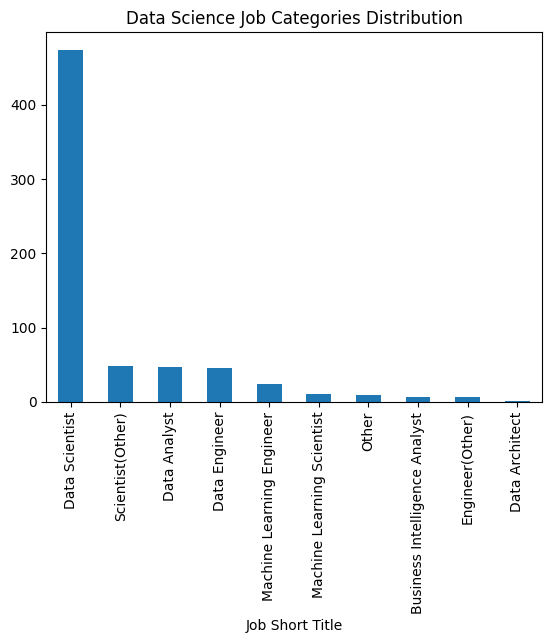

In [16]:
df['Job Short Title'].value_counts().plot(kind='bar')
plt.title('Data Science Job Categories Distribution')

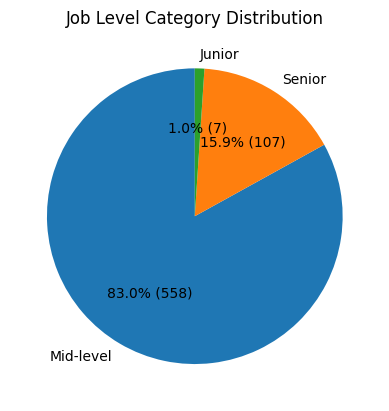

In [17]:
counts = df['Job Level'].value_counts()

plt.pie(
    counts, 
    labels=counts.index, 
    autopct=lambda pct: f'{pct:.1f}% ({int(round(pct/100 * counts.sum()))})',
    startangle=90
)
plt.title('Job Level Category Distribution')
plt.show()

In [18]:
#salary distribution
df['Salary Estimate'].describe()

count                             672
unique                             30
top       $79K-$131K (Glassdoor est.)
freq                               32
Name: Salary Estimate, dtype: object

In [19]:
df[['Salary Min','Salary Max']] = df['Salary Estimate'].str.extract(r'^(.*?)\s*-\s*(.*?)\s*\(')
df['Salary Min'] = df['Salary Min'].str.replace('K','000').str.replace('$','').astype(int)
df['Salary Max'] = df['Salary Max'].str.replace('K','000').str.replace('$','').astype(int)
df['Salary Avg'] = ((df['Salary Max'] + df ['Salary Min'])/2).astype(int)

In [20]:
salary_data = (
    df.groupby('Job Short Title')
      .agg(
          Salary_Min=('Salary Min', 'min'),
          Salary_Max=('Salary Max', 'max')
      )
      .sort_values('Salary_Max')
)

In [21]:
salary_data

,Salary_Min,Salary_Max
Job Short Title,,
Engineer(Other),56000,163000
Business Intelligence Analyst,31000,171000
Other,66000,171000
Data Architect,128000,201000
Data Engineer,31000,201000
Machine Learning Scientist,31000,201000
Data Analyst,31000,225000
Data Scientist,31000,331000
Machine Learning Engineer,56000,331000


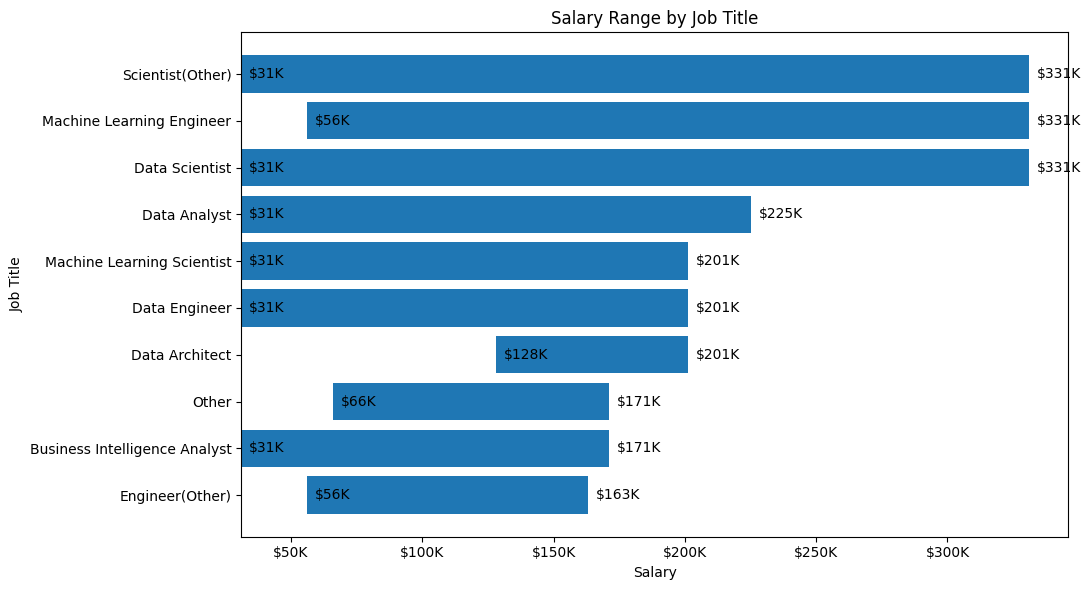

In [22]:
fig, ax = plt.subplots(figsize=(11, 6))

salary_range = salary_data['Salary_Max'] - salary_data['Salary_Min']

ax.barh(
    salary_data.index,
    salary_range,
    left=salary_data['Salary_Min']
)

for i, (minimum, maximum) in enumerate(
    zip(salary_data['Salary_Min'], salary_data['Salary_Max'])
):
    # Minimum salary
    ax.text(
        minimum + 3000,
        i,
        f'${minimum/1000:.0f}K',
        va='center',
        ha='left'
    )

    # Maximum salary
    ax.text(
        maximum + 3000,
        i,
        f'${maximum/1000:.0f}K',
        va='center',
        ha='left'
    )

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x/1000:.0f}K')
)

ax.set_xlabel('Salary')
ax.set_ylabel('Job Title')
ax.set_title('Salary Range by Job Title')

plt.tight_layout()
plt.show()

In [23]:
df.nlargest(20, 'Salary Max')[
    ['Job Title', 'Salary Min', 'Salary Max']
]

,Job Title,Salary Min,Salary Max
508,Senior Principal Data Scientist (Python/R),212000,331000
509,"Real World Science, Data Scientist",212000,331000
510,Data Scientist,212000,331000
511,Data Scientist(s)/Machine Learning Engineer,212000,331000
512,Senior Data Scientist,212000,331000
513,Data Scientist,212000,331000
514,Data Scientist,212000,331000
515,Data Scientist,212000,331000
516,ENGINEER - COMPUTER SCIENTIST - RESEARCH COMPU...,212000,331000
517,Data Scientist,212000,331000


In [24]:
skill_categories = {
    "Python": "Programming",
    "R": "Programming",
    "Java": "Programming",
    "Scala": "Programming",
    "C++": "Programming",
    "JavaScript": "Programming",
    "D3": "Programming",

    "Power BI": "BI & Analytics",
    "Tableau": "BI & Analytics",
    "Looker": "BI & Analytics",
    "Qlik": "BI & Analytics",
    "Excel": "BI & Analytics",

    "MySQL": "Database",
    "SQL": "Database",
    "PostgreSQL": "Database",
    "SQL Server": "Database",
    "Oracle": "Database",
    "MongoDB": "Database",

    "AWS": "Cloud",
    "Azure": "Cloud",
    "Google Cloud": "Cloud",
    "GCP": "Cloud",

    "Spark": "Data Engineering",
    "Hadoop": "Data Engineering",
    "Kafka": "Data Engineering",
    "ETL": "Data Engineering",
    "Databricks": "Data Engineering",
    "Snowflake": "Data Engineering",

    "Machine Learning": "Data Science",
    "Deep Learning": "Data Science",
    "NLP": "Data Science",
    "TensorFlow": "Data Science",
    "PyTorch": "Data Science",
    "Scikit-learn": "Data Science",

    "Statistics": "Analytics",
    "Data Analysis": "Analytics",
    "Data Visualization": "Analytics",
    "Predictive Modeling": "Analytics",
    "Forecasting": "Analytics"
}

In [25]:
def extract_skills(text):
    if pd.isna(text):
        return[]

    text = text.lower()
    found_skills = []

    for skill in skill_categories:

        pattern = r'\b' + re.escape(skill.lower()) + r'\b'

        if re.search(pattern,text):
            found_skills.append(skill)

    return(found_skills)
df["Skills"] = df["Job Description"].apply(extract_skills)

In [26]:
job_skills = df[['Job ID', 'Skills']].explode('Skills')

job_skills = job_skills.rename(
    columns ={ 'Skills' : 'Skill'}
)

job_skills = job_skills.dropna(subset=['Skill'])
job_skills = job_skills.reset_index(drop = True)

In [27]:
skill_dim = (
    job_skills[['Skill']]
    .drop_duplicates()
    .sort_values('Skill')
    .reset_index(drop = True)
)
skill_dim.insert(0, "Skill_ID", range(1, len(skill_dim) + 1))

In [28]:
job_skills = job_skills.merge( 
    skill_dim,
    on="Skill",
    how="left"
)

In [29]:
job_skills = job_skills.drop(columns=['Skill'])

In [30]:
skill_dim["Skill Category"] = skill_dim["Skill"].map(skill_categories)

In [31]:
skill_dim[skill_dim["Skill Category"].isna()]

,Skill_ID,Skill,Skill Category


In [32]:
skill_dim["Skill Category"].value_counts()

Skill Category
Programming         6
Data Engineering    6
Data Science        6
Database            6
Analytics           5
BI & Analytics      5
Cloud               4
Name: count, dtype: int64

In [33]:
skill_frequency = (
    job_skills
    .groupby("Skill_ID")
    .size()
    .reset_index(name="Job_Count")
)

In [34]:
s_df = skill_frequency.merge(
    skill_dim,
    on='Skill_ID',
    how='left'
)



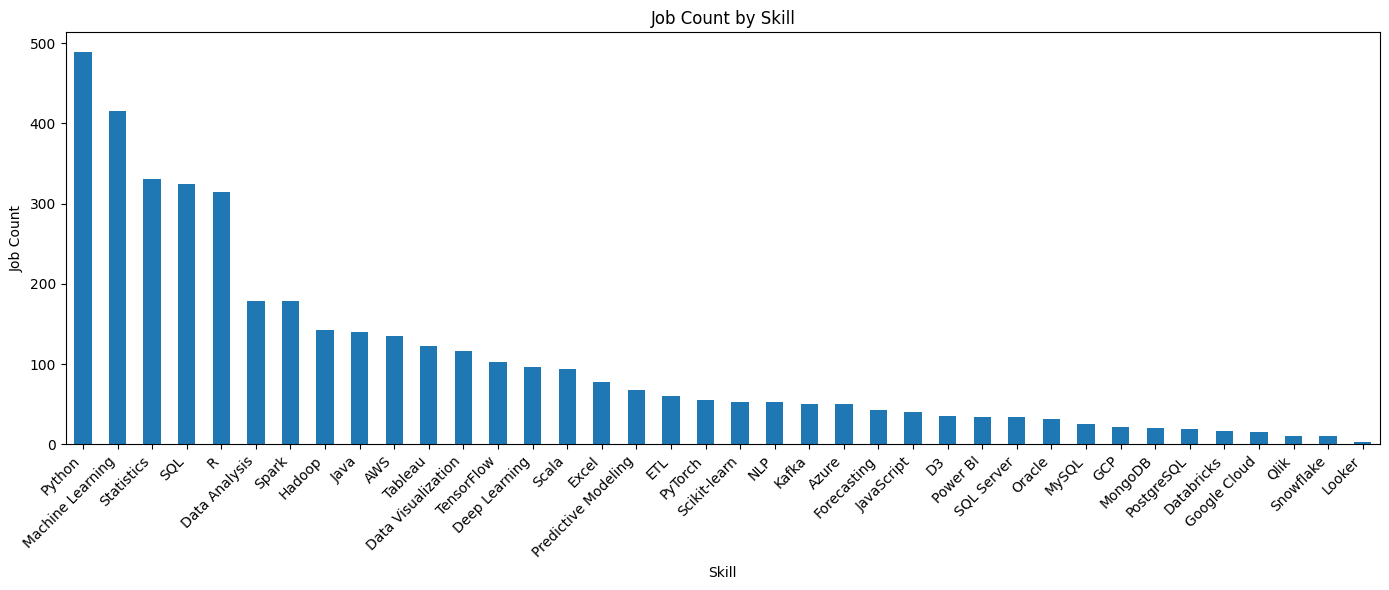

In [35]:
sorted_df = s_df.sort_values('Job_Count', ascending=False)

sorted_df.plot(
    kind='bar',
    x='Skill',
    y='Job_Count',
    figsize=(14, 6),
    legend=False
)

plt.title('Job Count by Skill')
plt.xlabel('Skill')
plt.ylabel('Job Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [36]:
# 1. How many jobs have at least one detected skill?
df['Skills'].apply(len).value_counts().sort_index()

Skills
0     27
1     41
2     52
3     38
4     60
5     99
6     83
7     70
8     46
9     61
10    32
11    18
12    17
13     9
14     9
15     9
16     1
Name: count, dtype: int64

In [37]:
# 2. How many jobs have no detected skills?
(df["Skills"].apply(len) == 0).sum()

np.int64(27)

In [38]:
# 3. What skills were actually extracted?
skill_dim["Skill"].tolist()

['AWS',
 'Azure',
 'D3',
 'Data Analysis',
 'Data Visualization',
 'Databricks',
 'Deep Learning',
 'ETL',
 'Excel',
 'Forecasting',
 'GCP',
 'Google Cloud',
 'Hadoop',
 'Java',
 'JavaScript',
 'Kafka',
 'Looker',
 'Machine Learning',
 'MongoDB',
 'MySQL',
 'NLP',
 'Oracle',
 'PostgreSQL',
 'Power BI',
 'Predictive Modeling',
 'PyTorch',
 'Python',
 'Qlik',
 'R',
 'SQL',
 'SQL Server',
 'Scala',
 'Scikit-learn',
 'Snowflake',
 'Spark',
 'Statistics',
 'Tableau',
 'TensorFlow']

In [39]:
df.drop(columns=['Salary Estimate','Job Description','Skills'],inplace=True)

In [ ]:
job_skills.to_csv('/job_skills.csv', index=False)
skill_dim.to_csv('/skill_dim.csv', index=False)
df.to_csv('/job_postings.csv', index=False)